## Read csv(50_startups), preprocess the data

#### categorical to numeric data, replace values of categorical data to numeric data

##### find the correlation among the feature

In [2]:
#import the  requried packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/home/sakshi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
import warnings
warnings.filterwarnings(action="ignore")


In [8]:
# load the data
df=pd.read_csv("50_Startups.csv")
df.head()
        

,RnD,Administration,Marketing,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [9]:
df.describe()


,RnD,Administration,Marketing,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RnD             50 non-null     float64
 1   Administration  50 non-null     float64
 2   Marketing       50 non-null     float64
 3   State           50 non-null     object 
 4   Profit          50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [11]:
#check if any data is missing
print(df.isna().sum())

RnD               0
Administration    0
Marketing         0
State             0
Profit            0
dtype: int64


## convert categorical column to numeric column

#### ordinal Encoder/OneHot Encoder/LabelEncoder

In [13]:
# step1: Find the unique state
unique_states = df['State'].unique()

In [14]:
print(unique_states)

['New York' 'California' 'Florida']


In [24]:
# step2 : replace the unique values with numbers
# Cleaner approach using a dictionary map
state_mapping = {'New York': 1, 'California': 2, 'Florida': 3}
df['State'] = df['State'].replace(state_mapping)


In [25]:
df.head()

,RnD,Administration,Marketing,State,Profit
0,165349.20,136897.80,471784.10,1,192261.83
1,162597.70,151377.59,443898.53,2,191792.06
2,153441.51,101145.55,407934.54,3,191050.39
3,144372.41,118671.85,383199.62,1,182901.99
4,142107.34,91391.77,366168.42,3,166187.94


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RnD             50 non-null     float64
 1   Administration  50 non-null     float64
 2   Marketing       50 non-null     float64
 3   State           50 non-null     object 
 4   Profit          50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [22]:
print(df.columns)

Index(['RnD', 'Administration', 'Marketing', 'State', 'Profit'], dtype='object')


In [26]:
df.corr()

,RnD,Administration,Marketing,State,Profit
RnD,1.000000,0.241955,0.724248,0.037930,0.972900
Administration,0.241955,1.000000,-0.032154,0.003026,0.200717
Marketing,0.724248,-0.032154,1.000000,0.137777,0.747766
State,0.037930,0.003026,0.137777,1.000000,0.048471
Profit,0.972900,0.200717,0.747766,0.048471,1.000000


In [27]:

print(f"Correlation for Profit and RnD = {df['Profit'].corr(df['RnD'])}")
print(f"Correlation for Profit and Administration = {df['Profit'].corr(df['Administration'])}")
print(f"Correlation for Profit and Marketing = {df['Profit'].corr(df['Marketing'])}")
print(f"Correlation for Profit and State = {df['Profit'].corr(df['State'])}")

Correlation for Profit and RnD = 0.9729004656594832
Correlation for Profit and Administration = 0.20071656826872125
Correlation for Profit and Marketing = 0.7477657217414766
Correlation for Profit and State = 0.04847097181537067


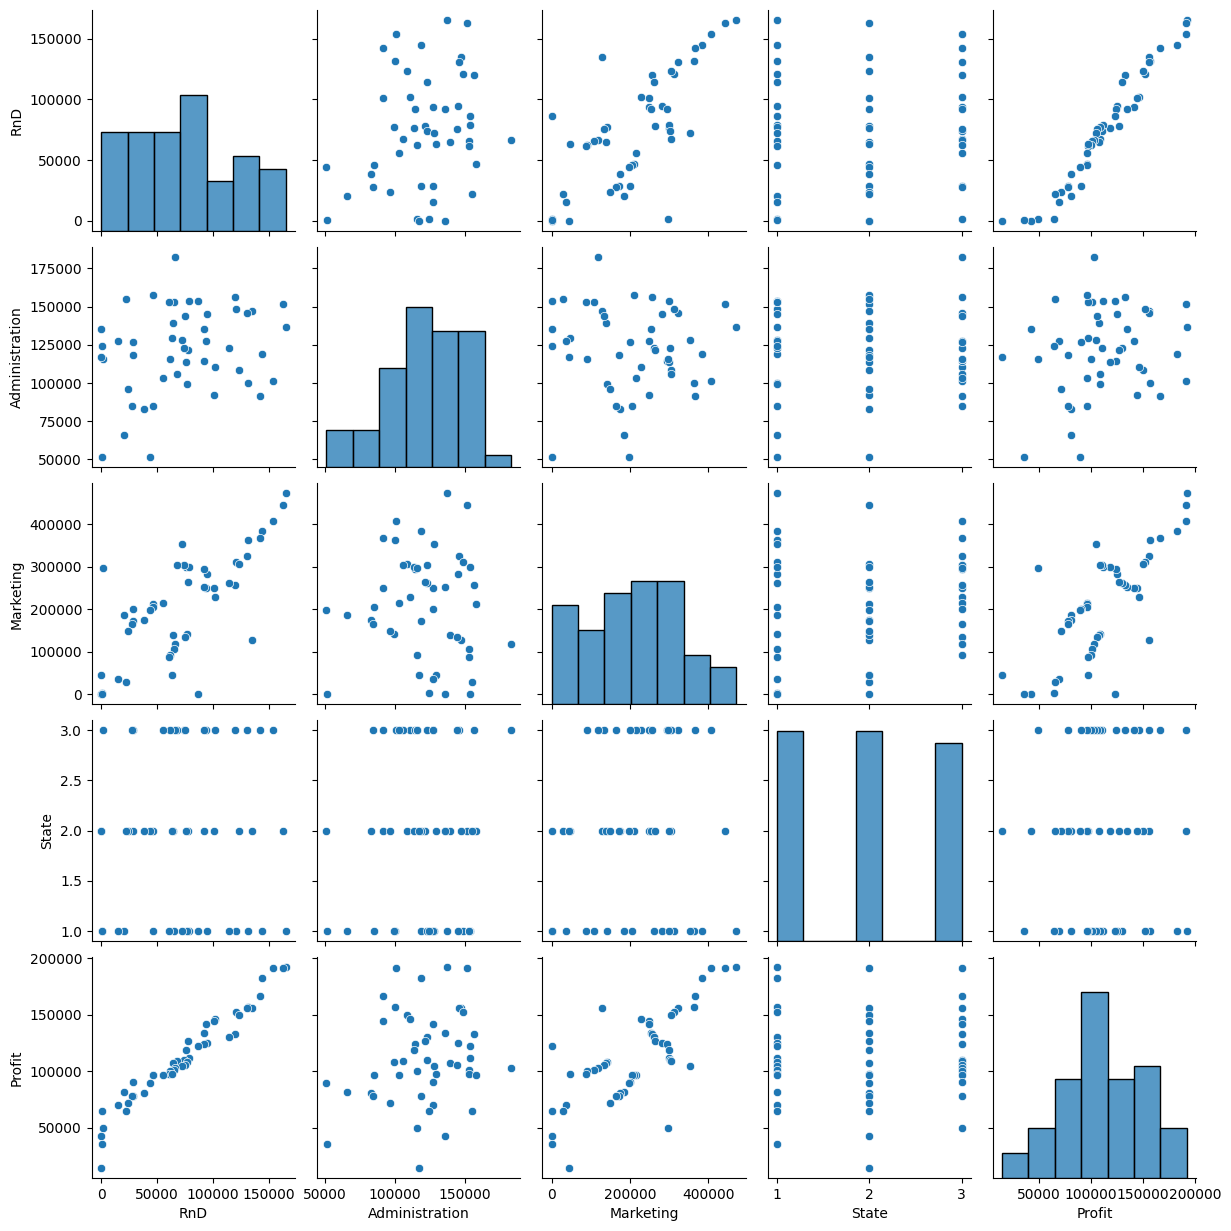

In [28]:
sns.pairplot(df)
plt.savefig('50_startups.jpg')

In [29]:
df.drop('state', axis=1, inplace=True)

KeyError: "['state'] not found in axis"

In [30]:
sns.heatmp(df.corr())

AttributeError: module 'seaborn' has no attribute 'heatmp'